In [2]:
!pip install rpy2

In [3]:
%load_ext rpy2.ipython

In [4]:
%%R
data <- read.csv("/content/train.csv")
head(data)

  PassengerId Survived Pclass
1           1        0      3
2           2        1      1
3           3        1      3
4           4        1      1
5           5        0      3
6           6        0      3
                                                 Name    Sex Age SibSp Parch
1                             Braund, Mr. Owen Harris   male  22     1     0
2 Cumings, Mrs. John Bradley (Florence Briggs Thayer) female  38     1     0
3                              Heikkinen, Miss. Laina female  26     0     0
4        Futrelle, Mrs. Jacques Heath (Lily May Peel) female  35     1     0
5                            Allen, Mr. William Henry   male  35     0     0
6                                    Moran, Mr. James   male  NA     0     0
            Ticket    Fare Cabin Embarked
1        A/5 21171  7.2500              S
2         PC 17599 71.2833   C85        C
3 STON/O2. 3101282  7.9250              S
4           113803 53.1000  C123        S
5           373450  8.0500              S

In [5]:
%%R

str(data)

summary(data)

dim(data)

names(data)

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        : chr  "male" "female" "female" "female" ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : chr  "A/5 21171" "PC 17599" "STON/O2. 3101282" "113803" ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : chr  "" "C85" "" "C123" ...
 $ Embarked   : chr  "S" "C" "S" "S" ...
 [1] "PassengerId" "Survived"    "Pclass"      "Name"        "Sex"        
 [6] "Age"         "SibSp"       "Parch"       "Ticket"      "Fare"       
[11] "Cabin"       "Embarked"   


In [48]:
%%R

missing_values <- colSums(is.na(data))

print(missing_values)

total_missing <- sum(is.na(data))

print(total_missing)

    PassengerId        Survived          Pclass            Name             Sex 
              0               0               0               0               0 
            Age           SibSp           Parch          Ticket            Fare 
              0               0               0               0               0 
          Cabin        Embarked     Fare_capped  Age_normalized Fare_normalized 
              0               0               0               0               0 
    Sex_encoded 
              0 
[1] 0


In [9]:
%%R

total_missing <- sum(is.na(data))

print(total_missing)

[1] 177


In [10]:
%%R

median_age <- median(data$Age, na.rm = TRUE)

print(median_age)

[1] 28


In [49]:
%%R

median_age <- median(data$Age, na.rm = TRUE)

print(median_age)

data$Age[is.na(data$Age)] <- median_age

colSums(is.na(data))

[1] 28
    PassengerId        Survived          Pclass            Name             Sex 
              0               0               0               0               0 
            Age           SibSp           Parch          Ticket            Fare 
              0               0               0               0               0 
          Cabin        Embarked     Fare_capped  Age_normalized Fare_normalized 
              0               0               0               0               0 
    Sex_encoded 
              0 


In [12]:
%%R

duplicate_count <- sum(duplicated(data))

print(duplicate_count)

[1] 0


In [13]:
%%R


data[duplicated(data), ]

 [1] PassengerId Survived    Pclass      Name        Sex         Age        
 [7] SibSp       Parch       Ticket      Fare        Cabin       Embarked   
<0 rows> (or 0-length row.names)


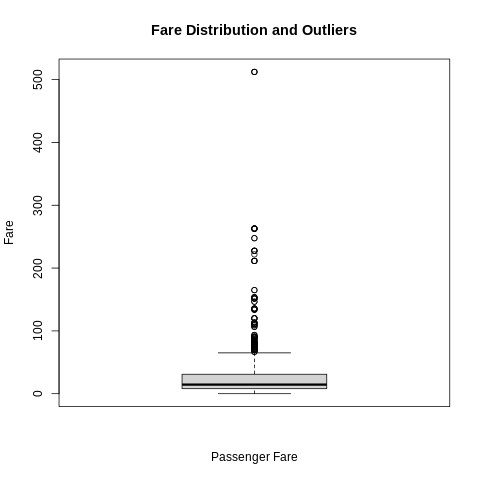

In [14]:
%%R

boxplot(
  data$Fare,
  main = "Fare Distribution and Outliers",
  ylab = "Fare",
  xlab = "Passenger Fare"
)

In [15]:
%%R

Q1 <- quantile(data$Fare, 0.25, na.rm = TRUE)
Q3 <- quantile(data$Fare, 0.75, na.rm = TRUE)

IQR_value <- IQR(data$Fare, na.rm = TRUE)

lower_limit <- Q1 - 1.5 * IQR_value
upper_limit <- Q3 + 1.5 * IQR_value

print(Q1)
print(Q3)
print(IQR_value)
print(lower_limit)
print(upper_limit)

   25% 
7.9104 
75% 
 31 
[1] 23.0896
    25% 
-26.724 
    75% 
65.6344 


In [16]:
%%R

outliers <- data$Fare[
  data$Fare < lower_limit |
  data$Fare > upper_limit
]

print(length(outliers))

[1] 116


In [18]:
%%R

data$Fare_capped <- data$Fare

data$Fare_capped[data$Fare_capped > upper_limit] <- upper_limit

data$Fare_capped[data$Fare_capped < lower_limit] <- lower_limit

summary(data$Fare_capped)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    7.91   14.45   24.05   31.00   65.63 


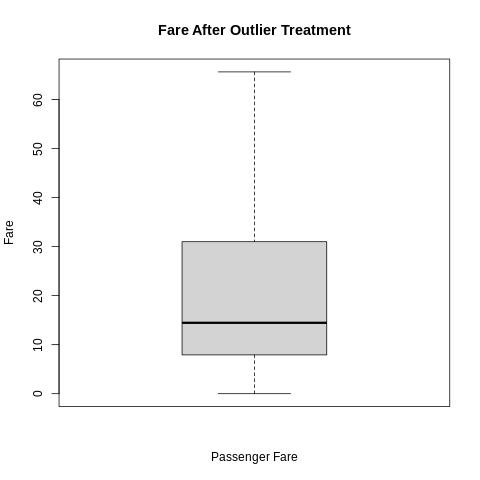

In [19]:
%%R

boxplot(
  data$Fare_capped,
  main = "Fare After Outlier Treatment",
  ylab = "Fare",
  xlab = "Passenger Fare"
)

In [20]:
%%R

min_max <- function(x) {
  (x - min(x, na.rm = TRUE)) /
    (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))
}

In [21]:
%%R

data$Age_normalized <- min_max(data$Age)

data$Fare_normalized <- min_max(data$Fare_capped)

head(data[, c(
  "Age",
  "Age_normalized",
  "Fare_capped",
  "Fare_normalized"
)])

  Age Age_normalized Fare_capped Fare_normalized
1  22      0.2711737      7.2500       0.1104604
2  38      0.4722292     65.6344       1.0000000
3  26      0.3214375      7.9250       0.1207446
4  35      0.4345313     53.1000       0.8090270
5  35      0.4345313      8.0500       0.1226491
6  28      0.3465695      8.4583       0.1288699


In [22]:
%%R

summary(data$Age_normalized)
summary(data$Fare_normalized)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.1205  0.2202  0.3664  0.4723  1.0000 


In [23]:
%%R

data$Sex_encoded <- ifelse(
  data$Sex == "male",
  1,
  0
)

head(data[, c("Sex", "Sex_encoded")])

     Sex Sex_encoded
1   male           1
2 female           0
3 female           0
4 female           0
5   male           1
6   male           1


In [24]:
%%R

embarked_encoded <- model.matrix(
  ~ Embarked - 1,
  data = data
)


head(embarked_encoded)

  Embarked EmbarkedC EmbarkedQ EmbarkedS
1        0         0         0         1
2        0         1         0         0
3        0         0         0         1
4        0         0         0         1
5        0         0         0         1
6        0         0         1         0


In [25]:
%%R

summary(data)

  PassengerId       Survived          Pclass             Name    
 Min.   :  1.0   Min.   :0.0000   Min.   :1.000   Length   :891  
 1st Qu.:223.5   1st Qu.:0.0000   1st Qu.:2.000   N.unique :891  
 Median :446.0   Median :0.0000   Median :3.000   N.blank  :  0  
 Mean   :446.0   Mean   :0.3838   Mean   :2.309   Min.nchar: 12  
 3rd Qu.:668.5   3rd Qu.:1.0000   3rd Qu.:3.000   Max.nchar: 82  
 Max.   :891.0   Max.   :1.0000   Max.   :3.000                  
        Sex           Age            SibSp           Parch       
 Length   :891   Min.   : 0.42   Min.   :0.000   Min.   :0.0000  
 N.unique :  2   1st Qu.:22.00   1st Qu.:0.000   1st Qu.:0.0000  
 N.blank  :  0   Median :28.00   Median :0.000   Median :0.0000  
 Min.nchar:  4   Mean   :29.36   Mean   :0.523   Mean   :0.3816  
 Max.nchar:  6   3rd Qu.:35.00   3rd Qu.:1.000   3rd Qu.:0.0000  
                 Max.   :80.00   Max.   :8.000   Max.   :6.0000  
       Ticket         Fare              Cabin          Embarked  
 Length   

In [26]:
%%R

summary(
  data[, c(
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Fare_capped"
  )]
)

      Age            SibSp           Parch             Fare       
 Min.   : 0.42   Min.   :0.000   Min.   :0.0000   Min.   :  0.00  
 1st Qu.:22.00   1st Qu.:0.000   1st Qu.:0.0000   1st Qu.:  7.91  
 Median :28.00   Median :0.000   Median :0.0000   Median : 14.45  
 Mean   :29.36   Mean   :0.523   Mean   :0.3816   Mean   : 32.20  
 3rd Qu.:35.00   3rd Qu.:1.000   3rd Qu.:0.0000   3rd Qu.: 31.00  
 Max.   :80.00   Max.   :8.000   Max.   :6.0000   Max.   :512.33  
  Fare_capped   
 Min.   : 0.00  
 1st Qu.: 7.91  
 Median :14.45  
 Mean   :24.05  
 3rd Qu.:31.00  
 Max.   :65.63  


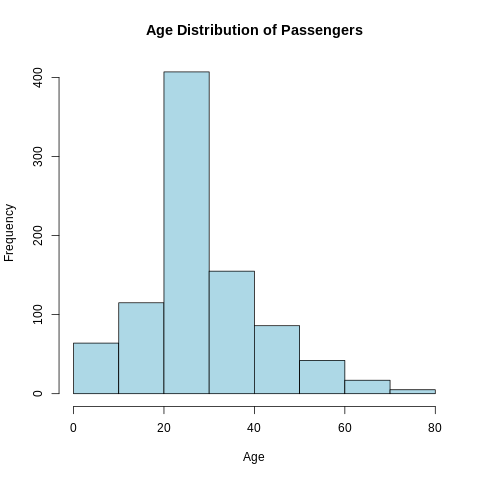

In [27]:
%%R

hist(
  data$Age,
  main = "Age Distribution of Passengers",
  xlab = "Age",
  ylab = "Frequency",
  col = "lightblue",
  border = "black"
)

In [28]:
%%R

gender_survival <- table(
  data$Sex,
  data$Survived
)

print(gender_survival)

        
           0   1
  female  81 233
  male   468 109


In [29]:
%%R

gender_survival_rate <- prop.table(
  table(data$Sex, data$Survived),
  margin = 1
) * 100

print(round(gender_survival_rate, 2))

        
             0     1
  female 25.80 74.20
  male   81.11 18.89


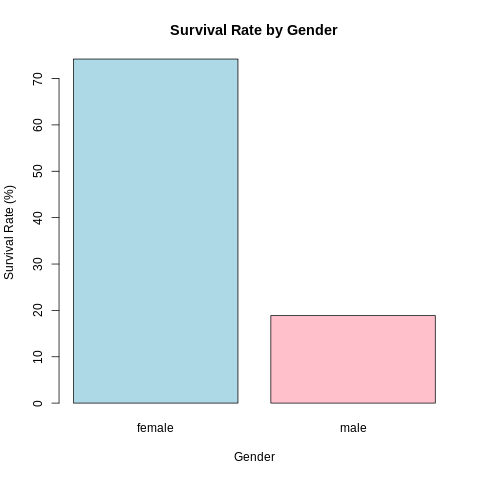

In [30]:
%%R

barplot(
  gender_survival_rate[, "1"],
  main = "Survival Rate by Gender",
  xlab = "Gender",
  ylab = "Survival Rate (%)",
  col = c("lightblue", "pink")
)

In [32]:
%%R

class_survival_rate <- prop.table(
  table(data$Pclass, data$Survived),
  margin = 1
) * 100

print(round(class_survival_rate, 2))

   
        0     1
  1 37.04 62.96
  2 52.72 47.28
  3 75.76 24.24


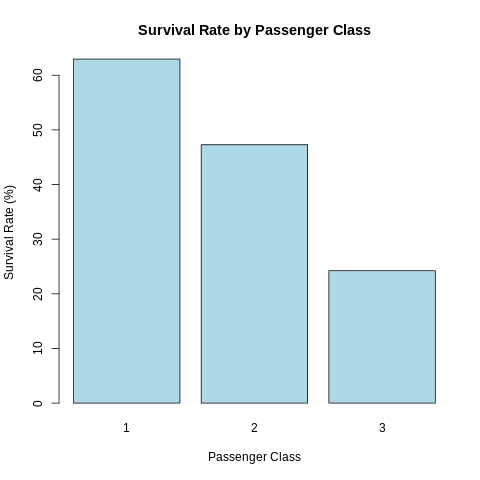

In [33]:
%%R

barplot(
  class_survival_rate[, "1"],
  main = "Survival Rate by Passenger Class",
  xlab = "Passenger Class",
  ylab = "Survival Rate (%)",
  col = "lightblue"
)

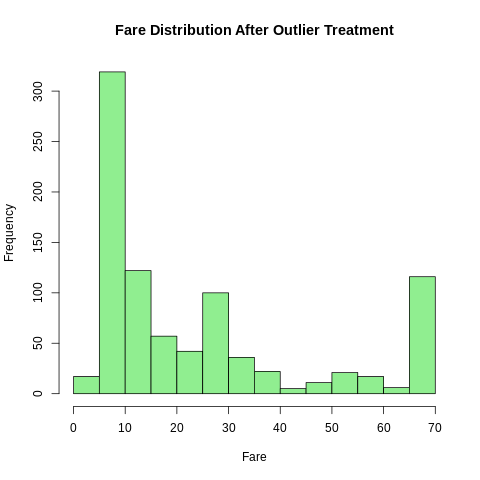

In [34]:
%%R

hist(
  data$Fare_capped,
  main = "Fare Distribution After Outlier Treatment",
  xlab = "Fare",
  ylab = "Frequency",
  col = "lightgreen",
  border = "black"
)

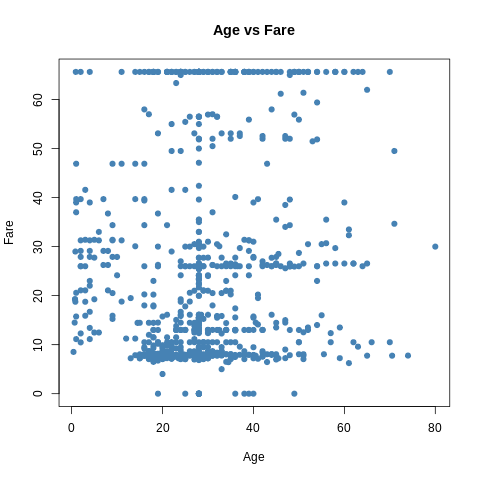

In [35]:
%%R

plot(
  data$Age,
  data$Fare_capped,
  main = "Age vs Fare",
  xlab = "Age",
  ylab = "Fare",
  pch = 19,
  col = "steelblue"
)

In [36]:
%%R

numeric_data <- data[, c(
  "Survived",
  "Pclass",
  "Age",
  "SibSp",
  "Parch",
  "Fare_capped"
)]

cor_matrix <- cor(
  numeric_data,
  use = "complete.obs"
)

print(round(cor_matrix, 3))

            Survived Pclass    Age  SibSp  Parch Fare_capped
Survived       1.000 -0.338 -0.065 -0.035  0.082       0.317
Pclass        -0.338  1.000 -0.340  0.083  0.018      -0.715
Age           -0.065 -0.340  1.000 -0.233 -0.172       0.144
SibSp         -0.035  0.083 -0.233  1.000  0.415       0.332
Parch          0.082  0.018 -0.172  0.415  1.000       0.293
Fare_capped    0.317 -0.715  0.144  0.332  0.293       1.000


In [37]:
%%R

survival_correlations <- cor_matrix[, "Survived"]

print(round(survival_correlations, 3))

   Survived      Pclass         Age       SibSp       Parch Fare_capped 
      1.000      -0.338      -0.065      -0.035       0.082       0.317 


In [38]:
%%R

numeric_data <- data[, c(
  "Survived",
  "Pclass",
  "Age",
  "SibSp",
  "Parch",
  "Fare_capped"
)]

cor_matrix <- cor(
  numeric_data,
  use = "complete.obs"
)

print(round(cor_matrix, 3))

            Survived Pclass    Age  SibSp  Parch Fare_capped
Survived       1.000 -0.338 -0.065 -0.035  0.082       0.317
Pclass        -0.338  1.000 -0.340  0.083  0.018      -0.715
Age           -0.065 -0.340  1.000 -0.233 -0.172       0.144
SibSp         -0.035  0.083 -0.233  1.000  0.415       0.332
Parch          0.082  0.018 -0.172  0.415  1.000       0.293
Fare_capped    0.317 -0.715  0.144  0.332  0.293       1.000


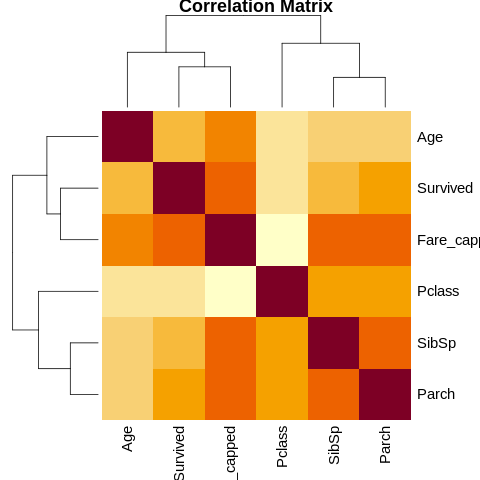

In [43]:
%%R

heatmap(
  cor_matrix,
  main = "Correlation Matrix",
  symm = TRUE
)

In [44]:
%%R

print(round(cor_matrix[, "Survived"], 3))

   Survived      Pclass         Age       SibSp       Parch Fare_capped 
      1.000      -0.338      -0.065      -0.035       0.082       0.317 


In [45]:
%%R


cat("Missing values after cleaning:\n")
print(colSums(is.na(data)))

cat("\nFinal dataset dimensions:\n")
print(dim(data))

cat("\nFinal dataset structure:\n")
str(data)

Missing values after cleaning:
    PassengerId        Survived          Pclass            Name             Sex 
              0               0               0               0               0 
            Age           SibSp           Parch          Ticket            Fare 
              0               0               0               0               0 
          Cabin        Embarked     Fare_capped  Age_normalized Fare_normalized 
              0               0               0               0               0 
    Sex_encoded 
              0 

Final dataset dimensions:
[1] 891  16

Final dataset structure:
'data.frame':	891 obs. of  16 variables:
 $ PassengerId    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived       : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass         : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name           : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        

In [46]:
%%R

write.csv(
  data,
  "/content/Titanic_Cleaned.csv",
  row.names = FALSE
)

cat("Cleaned dataset saved successfully.\n")

Cleaned dataset saved successfully.


In [47]:
%%R

cat("===== FINAL ANALYSIS SUMMARY =====\n")
cat("Original number of rows: 891\n")
cat("Final number of rows:", nrow(data), "\n")
cat("Missing Age values after cleaning:",
    sum(is.na(data$Age)), "\n")
cat("Duplicate rows:", sum(duplicated(data)), "\n")
cat("Fare outliers detected:", length(outliers), "\n")
cat("Fare upper outlier limit:", round(upper_limit, 4), "\n")
cat("Mean Age:", round(mean(data$Age), 2), "\n")
cat("Mean Fare before treatment:", round(mean(data$Fare), 2), "\n")
cat("Mean Fare after treatment:", round(mean(data$Fare_capped), 2), "\n")
cat("Overall survival rate:",
    round(mean(data$Survived) * 100, 2), "%\n")

===== FINAL ANALYSIS SUMMARY =====
Original number of rows: 891
Final number of rows: 891 
Missing Age values after cleaning: 0 
Duplicate rows: 0 
Fare outliers detected: 116 
Fare upper outlier limit: 65.6344 
Mean Age: 29.36 
Mean Fare before treatment: 32.2 
Mean Fare after treatment: 24.05 
Overall survival rate: 38.38 %
